In [ ]:
!pip install -q datasets pandas matplotlib seaborn transformers sentencepiece
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [ ]:
!pip install -q transformers datasets pandas
from transformers import AutoTokenizer
from datasets import Dataset


In [ ]:
# Load ParaDetox dataset from Hugging Face
dataset = load_dataset("s-nlp/paradetox")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/19744 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

# Convert the Hugging Face dataset to pandas DataFrame
df = dataset['train'].to_pandas()

# Rename columns for consistency
df["input_text"] = "Rewrite this comment politely: " + df["en_toxic_comment"]
df["target_text"] = df["en_neutral_comment"]

train_df = df[["input_text", "target_text"]]
train_df.head()

#went wroong

Shape: (19744, 2)


,toxic_comment,detoxified_comment
0,he had steel balls too !,he was brave too!
1,"dude should have been taken to api , he would ...",It would have been good if he went to api. He ...
2,"im not gonna sell the fucking picture , i just...","I'm not gonna sell the picture, i just want to..."
3,the garbage that is being created by cnn and o...,the news that is being created by cnn and othe...
4,the reason they dont exist is because neither ...,The reason they don't exist is because neither...


In [ ]:


# Show basic info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (19744, 2)


,toxic_comment,detoxified_comment
0,he had steel balls too !,he was brave too!
1,"dude should have been taken to api , he would ...",It would have been good if he went to api. He ...
2,"im not gonna sell the fucking picture , i just...","I'm not gonna sell the picture, i just want to..."
3,the garbage that is being created by cnn and o...,the news that is being created by cnn and othe...
4,the reason they dont exist is because neither ...,The reason they don't exist is because neither...


In [ ]:
df['toxic_len'] = df['toxic_comment'].str.split().apply(len)
df['detox_len'] = df['detoxified_comment'].str.split().apply(len)

stats = {
    "Total Samples": len(df),
    "Avg Toxic Length": round(df['toxic_len'].mean(), 2),
    "Avg Detoxified Length": round(df['detox_len'].mean(), 2),
    "Max Toxic Length": df['toxic_len'].max(),
    "Max Detoxified Length": df['detox_len'].max(),
}
pd.DataFrame([stats])


,Total Samples,Avg Toxic Length,Avg Detoxified Length,Max Toxic Length,Max Detoxified Length
0,19744,11.87,9.32,20,27


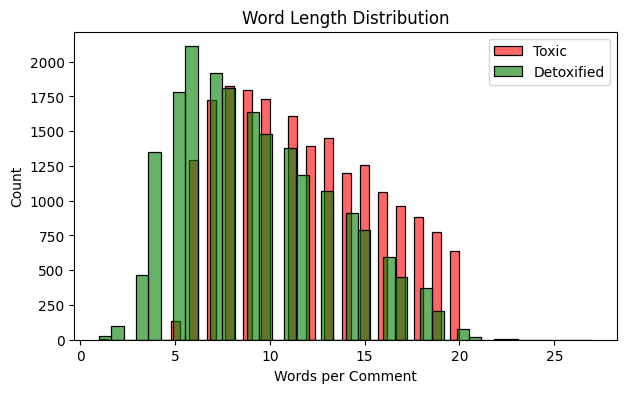

In [ ]:

plt.figure(figsize=(7,4))
sns.histplot(df['toxic_len'], bins=40, color='red', label='Toxic', alpha=0.6)
sns.histplot(df['detox_len'], bins=40, color='green', label='Detoxified', alpha=0.6)
plt.title('Word Length Distribution')
plt.xlabel('Words per Comment')
plt.legend()
plt.show()


In [ ]:
sample_df = df[['toxic_comment', 'detoxified_comment']].sample(20, random_state=42).reset_index(drop=True)
sample_df


,toxic_comment,detoxified_comment
0,anonymous is so fucking annoying .,anonymous is so annoying .
1,why would you fucking do anything else ?,Why would you do anything else?
2,"but it doess look good , just fucking shit sca...","but it doess look good , just scarringly good"
3,you really been on that wrestling shit again h...,"You've really been into wrestling again, huh?"
4,can we atleast listen to gospel if its gonna b...,can we at least listen to gospel if its gonna ...
5,"awww me too ! ! i wake up and im like "" fuck u...","I wake up and I'm like ,make love to me"
6,"i just realized , this guy didn 't do shit .","I just realized, this guy didn't do it."
7,awww bre let me do your tracs wait yu hair lon...,awww bre let me do your tracs wait yu hair lon...
8,if you don 't like me talking shit about cops,if you don’t like me talking negative statemen...
9,lmfaooo my legss tho ! make me put a mousetrap...,My legs! Make me put a mousetrap on my lips.


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df  = train_test_split(train_df, test_size=0.15, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("✅ Files saved: train.csv, val.csv, test.csv")


Train: 14264 | Val: 2518 | Test: 2962
✅ Files saved: train.csv, val.csv, test.csv


In [ ]:
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df.head()


Train: 14264 | Val: 2518 | Test: 2962


,toxic_comment,detoxified_comment,toxic_len,detox_len
0,fucking morons don 't know the difference betw...,they don 't know the difference between weathe...,12,11
1,somebody please tell him who the fuck i is ! !,Somebody please tell him who I is ?,11,8
2,its a sign for me to stop you asswipe,Its a sign for me to stop,9,7
3,how the fuck is wearing a full burka really a ...,How wearing a burka became a threat?,15,7
4,well they did some pretty horrific shit .,Well they did some pretty horrific things.,8,7


In [ ]:
def format_example(row):
    # prepend an instruction to guide the model
    return {
        "input_text": "Toxic: " + str(row["toxic_comment"]),
        "target_text": "Non-toxic: " + str(row["detoxified_comment"])
    }

train_df = train_df.apply(format_example, axis=1, result_type="expand")
val_df   = val_df.apply(format_example, axis=1, result_type="expand")
test_df  = test_df.apply(format_example, axis=1, result_type="expand")

train_df.head()


,input_text,target_text
0,Toxic: fucking morons don 't know the differen...,Non-toxic: they don 't know the difference bet...
1,Toxic: somebody please tell him who the fuck i...,Non-toxic: Somebody please tell him who I is ?
2,Toxic: its a sign for me to stop you asswipe,Non-toxic: Its a sign for me to stop
3,Toxic: how the fuck is wearing a full burka re...,Non-toxic: How wearing a burka became a threat?
4,Toxic: well they did some pretty horrific shit .,Non-toxic: Well they did some pretty horrific ...


In [ ]:
print(train_df.columns)


Index(['input_text', 'target_text'], dtype='object')


In [ ]:
model_checkpoint = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

max_input_length = 128
max_target_length = 128

def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["input_text"],       # Use 'input_text' from your DataFrame
        padding="max_length",
        truncation=True,
        max_length=max_input_length
    )
    labels = tokenizer(
        examples["target_text"],      # Use 'target_text' for labels
        padding="max_length",
        truncation=True,
        max_length=max_target_length
    )
    labels["input_ids"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels["input_ids"]
    ]
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs



config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_val = val_ds.map(preprocess_function, batched=True)
tokenized_test = test_ds.map(preprocess_function, batched=True)

Map:   0%|          | 0/14264 [00:00<?, ? examples/s]

Map:   0%|          | 0/2518 [00:00<?, ? examples/s]

Map:   0%|          | 0/2962 [00:00<?, ? examples/s]

In [ ]:
tokenized_train.save_to_disk("tokenized_train")
tokenized_val.save_to_disk("tokenized_val")
tokenized_test.save_to_disk("tokenized_test")

print("✅ Tokenized datasets saved for later use.")


Saving the dataset (0/1 shards):   0%|          | 0/14264 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2518 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2962 [00:00<?, ? examples/s]

✅ Tokenized datasets saved for later use.


In [ ]:
# !pip install -U transformers accelerate datasets evaluate


In [ ]:
!pip install -q transformers datasets accelerate sentencepiece
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, TrainingArguments, Trainer
from datasets import Dataset, load_from_disk


In [ ]:
model_checkpoint = "google/flan-t5-base"  # small for quick tests
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)



model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
train_df = train_df.rename(columns={"toxic": "input_text", "non_toxic": "target_text"})
val_df = val_df.rename(columns={"toxic": "input_text", "non_toxic": "target_text"})
test_df = test_df.rename(columns={"toxic": "input_text", "non_toxic": "target_text"})


In [ ]:
# import os
# os.environ["WANDB_DISABLED"] = "true"


In [ ]:
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Device in use:", device)



✅ Device in use: cuda


In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/flan_t5_detoxified",

    eval_strategy="steps",   # fix typo (was eval_strategy)
    eval_steps=100,

    save_strategy="steps",         # ✅ enable saving
    save_steps=200,                # save every 200 steps
    save_total_limit=2,            # keep only last 2 checkpoints

    num_train_epochs=2.5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-4,
    weight_decay=0.01,

    logging_steps=100,
    report_to="none",
    push_to_hub=False,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)


In [ ]:
trainer.train()


Step,Training Loss,Validation Loss
100,6.742590,4.616544
200,4.585281,3.436316
300,3.605700,2.789457
400,3.003485,2.414236
500,2.648926,2.144940
600,2.449764,1.952398
700,2.181998,1.784917
800,2.100078,1.670945
900,1.924203,1.585567
1000,1.846080,1.500051


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4458, training_loss=1.5755240516097837, metrics={'train_runtime': 6159.5064, 'train_samples_per_second': 5.789, 'train_steps_per_second': 0.724, 'total_flos': 6105296554426368.0, 'train_loss': 1.5755240516097837, 'epoch': 2.5002804262478966})

In [ ]:
trainer.save_model("flan_t5_toxic_to_positive")
tokenizer.save_pretrained("flan_t5_toxic_to_positive")
print("✅ Model and tokenizer saved successfully!")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved successfully!


In [ ]:
# trainer.train(resume_from_checkpoint=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!rm -rf /content/drive

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# Path on Google Drive
model_path = "/content/drive/MyDrive/toxic"

# Save the model and tokenizer
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)

print("Model and tokenizer saved successfully!")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully!


In [ ]:
# print(model)

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# Load locally from Drive
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path, local_files_only=True)
print("Model and tokenizer loaded successfully!")


In [ ]:
!pip install safetensors


In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_path = "/content/drive/MyDrive/toxic_to_positivee"

# Load tokenizer normally
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)

# Load model using safetensors
model2 = AutoModelForSeq2SeqLM.from_pretrained(
    model_path,
    local_files_only=True,
    trust_remote_code=True  # optional if using custom model
)

print("Model and tokenizer loaded successfully ✅")


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model and tokenizer loaded successfully ✅


In [ ]:
!ls /content/drive/MyDrive/toxic_to_positivee

config.json		model.safetensors      tokenizer.json
generation_config.json	tokenizer_config.json


In [ ]:
def test_model(sentences):
    for text in sentences:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
        outputs = model2.generate(**inputs, max_length=128)
        result = tokenizer.decode(outputs[0], skip_special_tokens=True)
        print(f"\n🔸 Input: {text}")
        print(f"🔹 Output: {result}")

# Example test cases
test_inputs = [
    "You are such an idiot!",
    "you are a fucking Bitch",
    "That was a stupid mistake",
     "suck my ass"
]

test_model(test_inputs)



🔸 Input: You are such an idiot!
🔹 Output: Non-toxic: You are not good

🔸 Input: you are a fucking Bitch
🔹 Output: Non-toxic: You are a bad person

🔸 Input: That was a stupid mistake
🔹 Output: Non-toxic: That was a mistake.

🔸 Input: suck my ass
🔹 Output: Non-toxic: I don't care.


In [ ]:
# !pip install evaluate sacrebleu rouge-score


In [ ]:
preds, refs = [], []

for text, expected in test_data:
    inputs = tokenizer(
        "Rewrite this politely: " + text,
        return_tensors="pt",
        truncation=True
    ).to(model.device)

    outputs = model.generate(**inputs, max_new_tokens=50)

    pred = tokenizer.decode(outputs[0], skip_special_tokens=True)

    preds.append(pred)
    refs.append(expected)

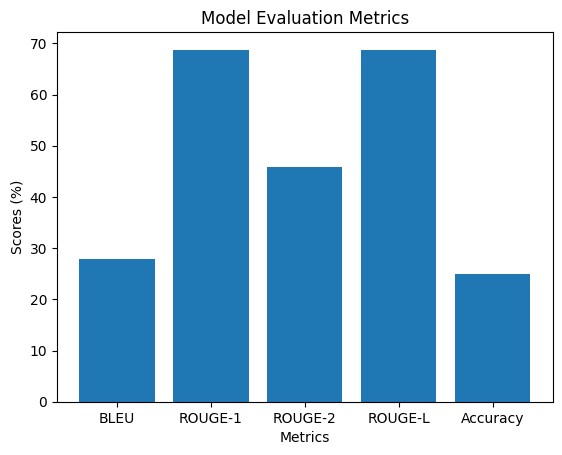

In [ ]:
# Visualization of evaluation results using matplotlib

import matplotlib.pyplot as plt

# Given results
metrics = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "Accuracy"]
values = [27.9, 0.6875*100, 0.4583*100, 0.6875*100, 25.0]  # scale ROUGE to %

# Create bar chart
plt.figure()
plt.bar(metrics, values)

plt.title("Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Scores (%)")

plt.show()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ✅ Load model
model_path = "/content/drive/MyDrive/toxic"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# ✅ Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()


In [ ]:

# 🔥 More harsh test examples
test_inputs = [
    "You are completely useless and nobody likes you.",
    "This is the dumbest thing I have ever seen.",
    "You always ruin everything.",
    "I hate you so much.",
    "You are a total failure in life.",
    "This is garbage work."
]

# ✅ Generate outputs
for text in test_inputs:
    prompt = "Rewrite this politely: " + text

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=50)

    pred = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print("\n" + "="*50)
    print("Input:      ", text)
    print("Output:     ", pred)


Input:       You are completely useless and nobody likes you.
Output:      Non-toxic: You are not good and nobody likes you.

Input:       This is the dumbest thing I have ever seen.
Output:      Non-toxic: This is the worst thing I have ever seen.

Input:       You always ruin everything.
Output:      Non-toxic: You always ruin everything.

Input:       I hate you so much.
Output:      Non-toxic: I hate you so much.

Input:       You are a total failure in life.
Output:      Non-toxic: You are not good in life.

Input:       This is garbage work.
Output:      Non-toxic: This is not good work.
